# 00 · Source profile: yc-oss companies feed

**Ticket:** YC-7 · **Goal:** decide whether the unofficial yc-oss feed can answer Q1 for the founder use case.

Sections:
1. Setup
2. Download one snapshot (only when `DOWNLOAD = True`)
3. Load and inspect structure
4. Field profiling (Findings 1, 3, 5; charts C1, C3)
5. Batch structure and coverage over time (Findings 2, 4; charts C2, C4, C5, C6)
6. Spot check (22 companies checked by hand)
7. Verdict

**To reproduce:** Kernel → Restart & Run All.

## 1. Setup

In [1]:
import hashlib
import json
from datetime import datetime, timezone
from pathlib import Path

import pandas as pd
import requests
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Find the repo root (the folder containing .git) so paths work
# whether the notebook is run from notebooks/ or the repo root.
ROOT = Path.cwd()
while not (ROOT / ".git").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

SOURCE_URL = "https://yc-oss.github.io/api/companies/all.json"
print("Repo root:", ROOT)

# Set to True only when you want a NEW snapshot. False = profile the latest saved one,
# so "Restart & Run All" never overwrites today's data.
DOWNLOAD = False

Repo root: c:\Users\dqthi\PlayGroundCoding\ycPortfolioAnalysis\yc-portfolio-analytics


## 2. Download one snapshot

Saves the raw bytes under `data/raw/<UTC date>/` (ignored by Git) plus a small manifest.
The SHA-256 checksum is a fingerprint: if it changes on a later download, the content changed.

**Run this once.** Re-running on the same day overwrites that day's snapshot.

In [ ]:
if DOWNLOAD:
    retrieved_at = datetime.now(timezone.utc)
    snapshot_dir = ROOT / "data" / "raw" / retrieved_at.strftime("%Y-%m-%d")
    snapshot_dir.mkdir(parents=True, exist_ok=True)

    response = requests.get(SOURCE_URL, timeout=30)
    response.raise_for_status()          # stop loudly on 4xx/5xx instead of saving an error page

    raw_bytes = response.content
    raw_path = snapshot_dir / "all.json"
    raw_path.write_bytes(raw_bytes)      # exact bytes as received, no reformatting

    manifest = {
        "source_url": SOURCE_URL,
        "retrieved_at_utc": retrieved_at.isoformat(),
        "http_status": response.status_code,
        "bytes": len(raw_bytes),
        "sha256": hashlib.sha256(raw_bytes).hexdigest(),
        "last_modified_header": response.headers.get("Last-Modified"),
    }
    (snapshot_dir / "manifest.json").write_text(json.dumps(manifest, indent=2))
    print(manifest)
else:
    print("DOWNLOAD = False: using the latest saved snapshot")

## 3. Load and inspect structure

To profile an existing snapshot without downloading again, set `SNAPSHOT_DATE` to a folder name under `data/raw/`.

In [4]:
SNAPSHOT_DATE = None   # e.g. "2026-09-26"; None = most recent snapshot

raw_root = ROOT / "data" / "raw"
dates = sorted(p.name for p in raw_root.iterdir() if p.is_dir())
snapshot = SNAPSHOT_DATE or dates[-1]
raw_path = raw_root / snapshot / "all.json"

records = json.loads(raw_path.read_text(encoding="utf-8"))
assert isinstance(records, list), "Expected a top-level JSON array"

df = pd.DataFrame(records)
print(f"Snapshot: {snapshot}  |  rows: {len(df):,}  |  columns: {df.shape[1]}")

Snapshot: 2026-09-25  |  rows: 6,248  |  columns: 29


In [5]:
# Which fields does the founder use case need, and are they all present?
NEEDED = ["id", "name", "one_liner", "long_description", "tags", "industry",
          "subindustry", "industries", "batch", "status", "stage", "team_size",
          "isHiring", "all_locations", "regions", "launched_at", "url"]

missing = [c for c in NEEDED if c not in df.columns]
print("Missing needed fields:", missing or "none")
print("\nAll columns:", sorted(df.columns))

Missing needed fields: none

All columns: ['all_locations', 'api', 'app_answers', 'app_video_public', 'batch', 'demo_day_video_public', 'former_names', 'id', 'industries', 'industry', 'isHiring', 'launched_at', 'long_description', 'name', 'nonprofit', 'one_liner', 'question_answers', 'regions', 'slug', 'small_logo_thumb_url', 'stage', 'status', 'subindustry', 'tags', 'tags_highlighted', 'team_size', 'top_company', 'url', 'website']


In [6]:
# Quick look at a few rows for the key fields
df[[c for c in NEEDED if c in df.columns]].head(5)

,id,name,one_liner,long_description,tags,industry,subindustry,industries,batch,status,stage,team_size,isHiring,all_locations,regions,launched_at,url
0,5,CircuitHub,On-Demand Electronics Manufacturing,CircuitHub offers on-demand electronics manufa...,"[Hard Tech, Hardware, Robotics, Manufacturing,...",Industrials,Industrials -> Manufacturing and Robotics,"[Industrials, Manufacturing and Robotics]",Winter 2012,Active,Early,58.0,True,"London, England, United Kingdom","[United Kingdom, Europe, Remote, Partly Remote]",1322045523,https://www.ycombinator.com/companies/circuithub
1,6,iCracked,On-demand smartphone repair in 3 countries and...,Founded in 2010 and located in the heart of Si...,[],Consumer,Consumer -> Home and Personal,"[Consumer, Home and Personal]",Winter 2012,Acquired,Growth,51.0,False,"San Francisco, CA, USA; Redwood City, CA, USA","[United States of America, America / Canada]",1322045532,https://www.ycombinator.com/companies/icracked
2,7,42Floors,We make it easy to search for office space.,*Acquired by Knotel in 2018\r\n\r\n42Floors wa...,"[Real Estate, Proptech]",Real Estate and Construction,Real Estate and Construction -> Housing and Re...,"[Real Estate and Construction, Housing and Rea...",Winter 2012,Acquired,Growth,60.0,False,"San Francisco, CA, USA; Remote","[United States of America, America / Canada, R...",1322045536,https://www.ycombinator.com/companies/42floors
3,8,PlanGrid,Mobile applications for the construction indus...,PlanGrid is the leader in construction product...,[Construction],Real Estate and Construction,Real Estate and Construction -> Construction,"[Real Estate and Construction, Construction]",Winter 2012,Acquired,Growth,355.0,False,"San Francisco, CA, USA","[United States of America, America / Canada]",1322045547,https://www.ycombinator.com/companies/plangrid
4,9,WireOver,Really secure file sending for big files.,WireOver is a desktop application that leverag...,"[Security, Enterprise]",B2B,B2B -> Productivity,"[B2B, Productivity]",Winter 2012,Inactive,Early,2.0,False,"Boston, MA, USA; Cambridge, MA, USA","[United States of America, America / Canada]",1322045564,https://www.ycombinator.com/companies/wireover


In [7]:
# Identity check: is `id` present and unique? (Duplicates would break every count.)
print("Null ids:", df["id"].isna().sum())
print("Duplicate ids:", df["id"].duplicated().sum())

Null ids: 0
Duplicate ids: 0


## 4. Field profiling

Types, missing values (null, empty text, empty list), placeholder values, and
the category hierarchy for every field the founder use case needs.

In [8]:
# ---- Chart helpers (used by every chart below) ----
# Fixed categorical palette, colour-blind-checked order. Colour follows the category.
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100",
           "#e87ba4", "#008300", "#4a3aa7", "#9a9994"]   # last = neutral grey for "Other"
BLUE, GREY, LIGHT_GREY = "#2a78d6", "#9a9994", "#d6d5d0"
INK, MUTED, GRID = "#0b0b0b", "#52514e", "#e4e3df"

def style(ax, grid_axis="y"):
    """Recessive axes: no box, light grid, muted ticks."""
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_color(MUTED)
    ax.tick_params(colors=MUTED, labelsize=9, length=0)
    ax.grid(axis=grid_axis, color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)

def titled(fig, title, note):
    """Left-aligned title plus a source/definition note under the chart."""
    fig.suptitle(title, x=0.01, ha="left", fontsize=13, color=INK, fontweight="bold")
    fig.text(0.01, 0.005, note, fontsize=8, color=MUTED)
    fig.tight_layout(rect=(0, 0.04, 1, 0.95))

In [9]:
# Which Python types appear in each field? (A consistent type can still hide empty values.)
for v in NEEDED:
    print(df[v].map(type).value_counts(), "\n")

id
<class 'int'>    6248
Name: count, dtype: int64 

name
<class 'str'>    6248
Name: count, dtype: int64 

one_liner
<class 'str'>    6248
Name: count, dtype: int64 

long_description
<class 'str'>         6219
<class 'NoneType'>      29
Name: count, dtype: int64 

tags
<class 'list'>    6248
Name: count, dtype: int64 

industry
<class 'str'>    6248
Name: count, dtype: int64 

subindustry
<class 'str'>    6248
Name: count, dtype: int64 

industries
<class 'list'>    6248
Name: count, dtype: int64 

batch
<class 'str'>    6248
Name: count, dtype: int64 

status
<class 'str'>    6248
Name: count, dtype: int64 

stage
<class 'str'>    6248
Name: count, dtype: int64 

team_size
<class 'float'>    6248
Name: count, dtype: int64 

isHiring
<class 'bool'>    6248
Name: count, dtype: int64 

all_locations
<class 'str'>    6248
Name: count, dtype: int64 

regions
<class 'list'>    6248
Name: count, dtype: int64 

launched_at
<class 'int'>    6248
Name: count, dtype: int64 

url
<class 'str'> 

In [10]:
def missing_profile(s):
    return {
        "null": s.isna().sum(),                                    # None / NaN
        "empty_str": s.map(lambda v: isinstance(v, str) and v.strip() == "").sum(),
        "empty_list": s.map(lambda v: isinstance(v, list) and len(v) == 0).sum(),
    }

results = {}
for v in NEEDED:
    results[v] = missing_profile(df[v])

pd.DataFrame(results).T

,null,empty_str,empty_list
id,0,0,0
name,0,0,0
one_liner,0,160,0
long_description,29,389,0
tags,0,0,869
industry,0,0,0
subindustry,0,0,0
industries,0,0,0
batch,0,0,0
status,0,0,0


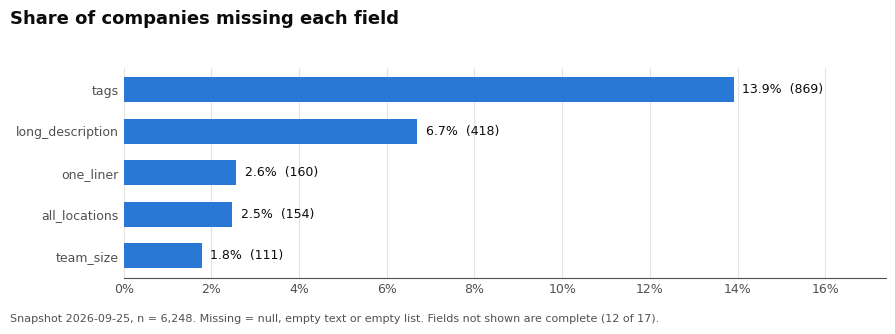

In [11]:
# C1 · Missing values by field (Finding 1)
miss = pd.DataFrame(results).T
miss["total"] = miss.sum(axis=1)
miss["pct"] = miss["total"] / len(df)
plot = miss[miss["total"] > 0].sort_values("pct")

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.barh(plot.index, plot["pct"], color=BLUE, height=0.6)
for y, (pct, n) in enumerate(zip(plot["pct"], plot["total"])):
    ax.text(pct + 0.002, y, f"{pct:.1%}  ({n:,})", va="center", fontsize=9, color=INK)
style(ax, grid_axis="x")
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
ax.set_xlim(0, plot["pct"].max() * 1.25)
titled(fig, "Share of companies missing each field",
       f"Snapshot {snapshot}, n = {len(df):,}. Missing = null, empty text or empty list. "
       f"Fields not shown are complete ({len(miss) - len(plot)} of {len(miss)}).")
plt.show()

### Finding 1: Missing values across needed fields

Snapshot: 6,248 companies. Missing values were counted three ways (null,
empty string, empty list), because a consistent data type hides empty values.

| Field | Missing | % | Form |
|---|---|---|---|
| tags | 869 | 13.9% | empty list |
| long_description | 418 | 6.7% | 29 null + 389 empty string |
| one_liner | 160 | 2.6% | empty string |
| all_locations | 154 | 2.5% | empty string |
| team_size | 111 | 1.8% | null (why the column is float) |

All other needed fields are complete. Placeholder values (e.g. "Unspecified")
are checked separately below.

In [12]:
for col in ["industry", "status", "stage"]:
    print(df[col].value_counts(), "\n")

print(sorted(df["batch"].unique()))

industry
B2B                             3178
Consumer                         885
Healthcare                       700
Fintech                          662
Industrials                      475
Real Estate and Construction     162
Education                        125
Government                        43
Unspecified                       18
Name: count, dtype: int64 

status
Active      4321
Inactive    1080
Acquired     824
Public        23
Name: count, dtype: int64 

stage
Early     5157
Growth    1091
Name: count, dtype: int64 

['Fall 2024', 'Fall 2025', 'Fall 2026', 'Spring 2025', 'Spring 2026', 'Summer 2005', 'Summer 2006', 'Summer 2007', 'Summer 2008', 'Summer 2009', 'Summer 2010', 'Summer 2011', 'Summer 2012', 'Summer 2013', 'Summer 2014', 'Summer 2015', 'Summer 2016', 'Summer 2017', 'Summer 2018', 'Summer 2019', 'Summer 2020', 'Summer 2021', 'Summer 2022', 'Summer 2023', 'Summer 2024', 'Summer 2025', 'Summer 2026', 'Summer 2027', 'Unspecified', 'Winter 2006', 'Winter 2007', 'Wi

In [13]:
df['subindustry'].value_counts()

subindustry
B2B                                                        644
B2B -> Engineering, Product and Design                     621
B2B -> Infrastructure                                      327
B2B -> Productivity                                        232
Fintech                                                    173
Consumer                                                   171
B2B -> Marketing                                           167
Industrials -> Manufacturing and Robotics                  157
B2B -> Operations                                          154
B2B -> Finance and Accounting                              142
Healthcare -> Healthcare IT                                141
B2B -> Supply Chain and Logistics                          140
B2B -> Sales                                               136
B2B -> Retail                                              127
Education                                                  125
B2B -> Analytics                           

In [14]:
# Companies whose subindustry has no child level ("B2B" instead of "B2B -> Legal").
# Education and Government never have a child level, so parent-only is expected there.
NO_CHILD_LEVEL = ["Education", "Government", "Unspecified"]
df["no_subindustry"] = (~df["subindustry"].str.contains(" -> ")
                        & ~df["subindustry"].isin(NO_CHILD_LEVEL))
print(f"Parent-only subindustry: {df['no_subindustry'].sum():,} "
      f"({df['no_subindustry'].mean():.1%})")
df.groupby("industry")["no_subindustry"].agg(["sum", "size", "mean"]).sort_values("size", ascending=False)

Parent-only subindustry: 1,166 (18.7%)


,sum,size,mean
industry,,,
B2B,644,3178,0.202643
Consumer,171,885,0.193220
Healthcare,108,700,0.154286
Fintech,173,662,0.261329
Industrials,44,475,0.092632
Real Estate and Construction,26,162,0.160494
Education,0,125,0.000000
Government,0,43,0.000000
Unspecified,0,18,0.000000


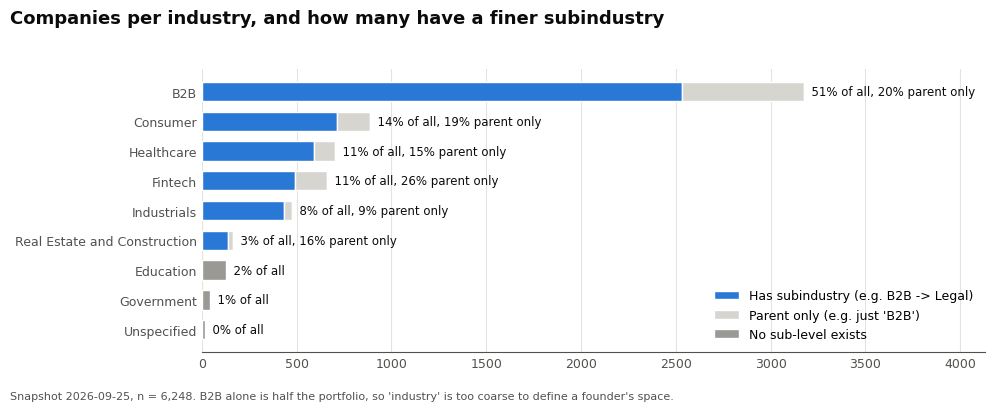

In [15]:
# C3 · Industry size and subindustry coverage (Finding 3)
ind = df.groupby("industry").agg(total=("id", "size"), parent_only=("no_subindustry", "sum"))
ind["no_level"] = ind.index.isin(NO_CHILD_LEVEL) * ind["total"]          # no child level exists
ind["with_child"] = ind["total"] - ind["parent_only"] - ind["no_level"]
ind = ind.sort_values("total")

fig, ax = plt.subplots(figsize=(10, 4))
left = pd.Series(0, index=ind.index)
for colname, color, label in [("with_child", BLUE, "Has subindustry (e.g. B2B -> Legal)"),
                              ("parent_only", LIGHT_GREY, "Parent only (e.g. just 'B2B')"),
                              ("no_level", GREY, "No sub-level exists")]:
    ax.barh(ind.index, ind[colname], left=left, color=color, height=0.65,
            edgecolor="white", linewidth=1, label=label)
    left += ind[colname]
for y, (tot, po) in enumerate(zip(ind["total"], ind["parent_only"])):
    share = f"  {tot / len(df):.0%} of all" + (f", {po / tot:.0%} parent only" if po else "")
    ax.text(tot, y, share, va="center", fontsize=8.5, color=INK)
style(ax, grid_axis="x")
ax.set_xlim(0, ind["total"].max() * 1.3)
ax.legend(loc="lower right", frameon=False, fontsize=9)
titled(fig, "Companies per industry, and how many have a finer subindustry",
       f"Snapshot {snapshot}, n = {len(df):,}. B2B alone is half the portfolio, so 'industry' is too coarse "
       "to define a founder's space.")
plt.show()

### Finding 3: `subindustry` is a usable two-level hierarchy, with gaps

`subindustry` is written `Parent -> Child` (about 59 values, matching the
yc-oss README). `industry` alone is too coarse for the founder use case:
B2B is 3,178 companies, 51% of the portfolio. The child level
(e.g. `B2B -> Legal`, 60 companies) is specific enough to describe an
**application** space.

**Gap:** 1,166 companies (18.7%) have only the parent level (e.g. just "B2B").
Education and Government never have a child level, so they are not counted
as missing; 18 companies have "Unspecified" industry. The gap is larger in
recent periods (about 30% of companies from 2024 onward, versus near 0%
before 2010), so it affects the founder's main window.

**Implication:** a founder's space = subindustry (application) + keyword in
`one_liner` (solution). Parent-only companies can still be found by keyword.

In [16]:
df[['industries','name','one_liner','subindustry','tags_highlighted']][df['name'] == "Bryel"]  

,industries,name,one_liner,subindustry,tags_highlighted
6197,"[B2B, Infrastructure]",Bryel,Devin for AI Research Engineering,B2B -> Infrastructure,[]


### Finding 5 *(draft — edit)*: YC pages show `tags`, not the category hierarchy

YC company pages display `tags` (e.g. Bryel: "B2B", "AI"), while `industry` /
`subindustry` form a separate hierarchy (Bryel: `B2B -> Infrastructure`).
The two can describe the same company differently. Tags mix application
labels ("B2B") and technology labels ("AI"). The spot check compared the
category fields, and both sources agreed.

## 5. Batch structure and coverage over time

Batch labels, the four-batch cadence change, half-year periods, and how
coverage (tags, companies per period) changes over time.

In [17]:
sorted(df["batch"].unique())

['Fall 2024',
 'Fall 2025',
 'Fall 2026',
 'Spring 2025',
 'Spring 2026',
 'Summer 2005',
 'Summer 2006',
 'Summer 2007',
 'Summer 2008',
 'Summer 2009',
 'Summer 2010',
 'Summer 2011',
 'Summer 2012',
 'Summer 2013',
 'Summer 2014',
 'Summer 2015',
 'Summer 2016',
 'Summer 2017',
 'Summer 2018',
 'Summer 2019',
 'Summer 2020',
 'Summer 2021',
 'Summer 2022',
 'Summer 2023',
 'Summer 2024',
 'Summer 2025',
 'Summer 2026',
 'Summer 2027',
 'Unspecified',
 'Winter 2006',
 'Winter 2007',
 'Winter 2008',
 'Winter 2009',
 'Winter 2010',
 'Winter 2011',
 'Winter 2012',
 'Winter 2013',
 'Winter 2014',
 'Winter 2015',
 'Winter 2016',
 'Winter 2017',
 'Winter 2018',
 'Winter 2019',
 'Winter 2020',
 'Winter 2021',
 'Winter 2022',
 'Winter 2023',
 'Winter 2024',
 'Winter 2025',
 'Winter 2026',
 'Winter 2027']

In [18]:
df["batch"].value_counts().loc[["Fall 2026", "Winter 2027", "Summer 2027"]]

batch
Fall 2026      91
Winter 2027     1
Summer 2027     1
Name: count, dtype: int64

In [19]:
# Which half of the year each season belongs to.
# Spring and Fall only exist from 2024–25, when YC moved to 4 batches a year.
SEASON_TO_HALF = {"Winter": "H1", "Spring": "H1", "Summer": "H2", "Fall": "H2"}

def batch_period(label):
    """Convert a batch label like 'Spring 2025' to a period like '2025-H1'.
    Returns None for labels that can't be placed in time (e.g. 'Unspecified')."""
    parts = str(label).split()                     # "Spring 2025" -> ["Spring", "2025"]
    if len(parts) != 2:                            # guards "Unspecified" or odd formats
        return None
    season, year = parts
    if season not in SEASON_TO_HALF or not year.isdigit():
        return None                                # unknown season or non-numeric year
    return f"{year}-{SEASON_TO_HALF[season]}"      # e.g. "2025-H1"

df["period"] = df["batch"].map(batch_period)
df["period"].value_counts().sort_index()

period
2005-H2      9
2006-H1      7
2006-H2     10
2007-H1     13
2007-H2     19
2008-H1     21
2008-H2     22
2009-H1     16
2009-H2     26
2010-H1     27
2010-H2     36
2011-H1     45
2011-H2     60
2012-H1     66
2012-H2     83
2013-H1     46
2013-H2     52
2014-H1     74
2014-H2     78
2015-H1    110
2015-H2    104
2016-H1    122
2016-H2    102
2017-H1    116
2017-H2    125
2018-H1    146
2018-H2    131
2019-H1    194
2019-H2    174
2020-H1    228
2020-H2    209
2021-H1    335
2021-H2    391
2022-H1    398
2022-H2    233
2023-H1    274
2023-H2    220
2024-H1    248
2024-H2    342
2025-H1    308
2025-H2    312
2026-H1    392
2026-H2    321
2027-H1      1
2027-H2      1
Name: count, dtype: int64

In [20]:
df["no_tags"] = df["tags"].map(len).eq(0)
df.groupby("batch")["no_tags"].agg(["mean", "size"]).sort_values("mean", ascending=False).head(15)

,mean,size
batch,,
Unspecified,1.000000,1
Summer 2005,0.777778,9
Winter 2026,0.748744,199
Summer 2007,0.736842,19
Spring 2026,0.720207,193
Winter 2006,0.714286,7
Winter 2008,0.666667,21
Winter 2010,0.629630,27
Summer 2008,0.590909,22


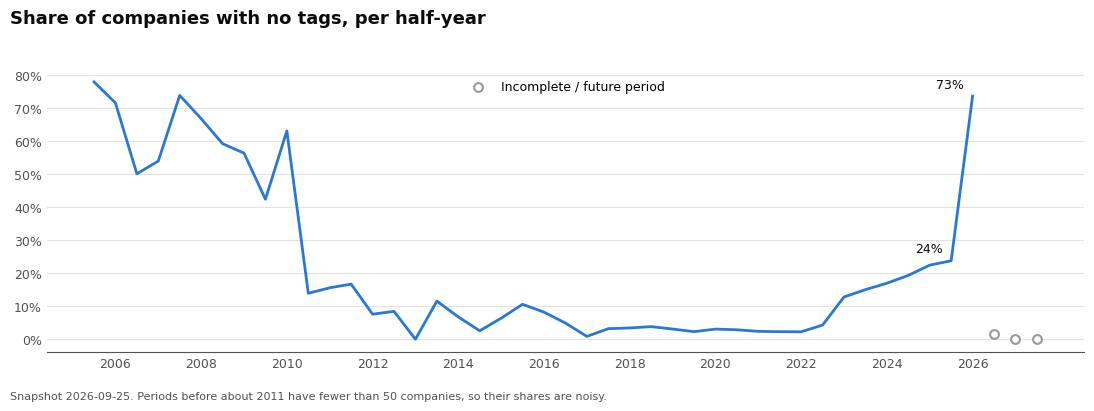

,n,untagged
period,,
2025-H1,308,0.224026
2025-H2,312,0.237179
2026-H1,392,0.734694
2026-H2,321,0.015576
2027-H1,1,0.000000
2027-H2,1,0.000000


In [21]:
# C2 · Share of companies with no tags, per half-year (Finding 2)
IN_PROGRESS_BATCHES = ["Fall 2026"]            # batches still running on the snapshot date
cutoff = min(batch_period(b) for b in IN_PROGRESS_BATCHES)

tag_gap = (df[df["period"].notna()]
           .groupby("period").agg(n=("id", "size"), untagged=("no_tags", "mean")))
complete = tag_gap[tag_gap.index < cutoff]
partial = tag_gap[tag_gap.index >= cutoff]

fig, ax = plt.subplots(figsize=(11, 4))
xs = list(tag_gap.index)
ax.plot([xs.index(p) for p in complete.index], complete["untagged"], color=BLUE, linewidth=2)
ax.scatter([xs.index(p) for p in partial.index], partial["untagged"], s=40,
           facecolors="white", edgecolors=GREY, linewidths=1.5, zorder=3,
           label="Incomplete / future period")
for p in ["2025-H2", "2026-H1"]:
    ax.annotate(f"{tag_gap.loc[p, 'untagged']:.0%}", (xs.index(p), tag_gap.loc[p, "untagged"]),
                xytext=(-6, 6), textcoords="offset points", ha="right", fontsize=9, color=INK)
style(ax)
ticks = [i for i, p in enumerate(xs) if p.endswith("H1") and int(p[:4]) % 2 == 0]
ax.set_xticks(ticks, [xs[i][:4] for i in ticks])
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
ax.legend(loc="upper center", frameon=False, fontsize=9)
titled(fig, "Share of companies with no tags, per half-year",
       f"Snapshot {snapshot}. Periods before about 2011 have fewer than 50 companies, so their shares are noisy.")
plt.show()
tag_gap.tail(6)

### Finding 2: Missing tags are concentrated in the newest batches

About a third of untagged companies (~288 of 869) come from the two newest
batches: 75% of Winter 2026 (149 of 199) and 72% of Spring 2026 (139 of 193)
have no tags, compared with 23–28% for the 2025 batches. The oldest batches
(2005–2010) are also poorly tagged (42–78%), but they are small, together
about 100 companies. One company has batch "Unspecified" and is excluded
from time-based analysis.

The gradient from newest to middle years suggests tags are added some time
after a company joins YC. This is a hypothesis, testable by comparing this
snapshot with a later one.

**Implication for the founder use case:** tags cannot reliably define a
solution space for recent batches, which is the founder's main window.
`one_liner` (2.6% missing) and `industry` (0% missing) are the more reliable
basis. This informs the brief's open question on how a founder defines
their space.

**Check against Finding 2 (from chart C2):** the most recent period with
data, 2026-H2 (Summer 2026 + the in-progress Fall 2026), is only about 2%
untagged, while 2026-H1 (Winter + Spring 2026) is about 74% untagged. If
tags were simply added over time, the newest batches should be the *least*
tagged. This weakens the "tags are added later" hypothesis in Finding 2.
Another explanation, such as a change in how Winter and Spring 2026 were
tagged, may fit better. Revise Finding 2 before the verdict.

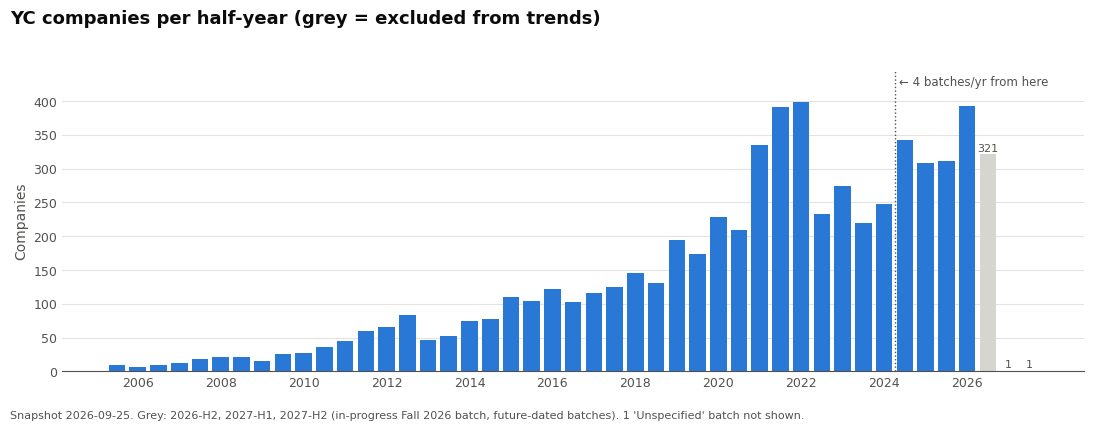

In [22]:
# C4 · Companies per half-year period, with exclusions marked (Finding 4)
per = df["period"].value_counts().sort_index()
excluded = [p for p in per.index if p >= cutoff]

fig, ax = plt.subplots(figsize=(11, 4.2))
xs = list(per.index)
ax.bar(range(len(xs)), per.values, width=0.8,
       color=[LIGHT_GREY if p in excluded else BLUE for p in xs])
cad = xs.index("2024-H2")
ax.axvline(cad - 0.5, color=MUTED, linestyle=":", linewidth=1)
ax.set_ylim(0, per.max() * 1.12)
ax.text(cad - 0.3, per.max() * 1.1, "← 4 batches/yr from here", ha="left", va="top", fontsize=8.5, color=MUTED)
for p in excluded:
    ax.text(xs.index(p), per[p] + 5, f"{per[p]}", ha="center", fontsize=8, color=MUTED)
style(ax)
ticks = [i for i, p in enumerate(xs) if p.endswith("H1") and int(p[:4]) % 2 == 0]
ax.set_xticks(ticks, [xs[i][:4] for i in ticks])
ax.set_ylabel("Companies", color=MUTED)
titled(fig, "YC companies per half-year (grey = excluded from trends)",
       f"Snapshot {snapshot}. Grey: {', '.join(excluded)} (in-progress Fall 2026 batch, future-dated batches). "
       "1 'Unspecified' batch not shown.")
plt.show()

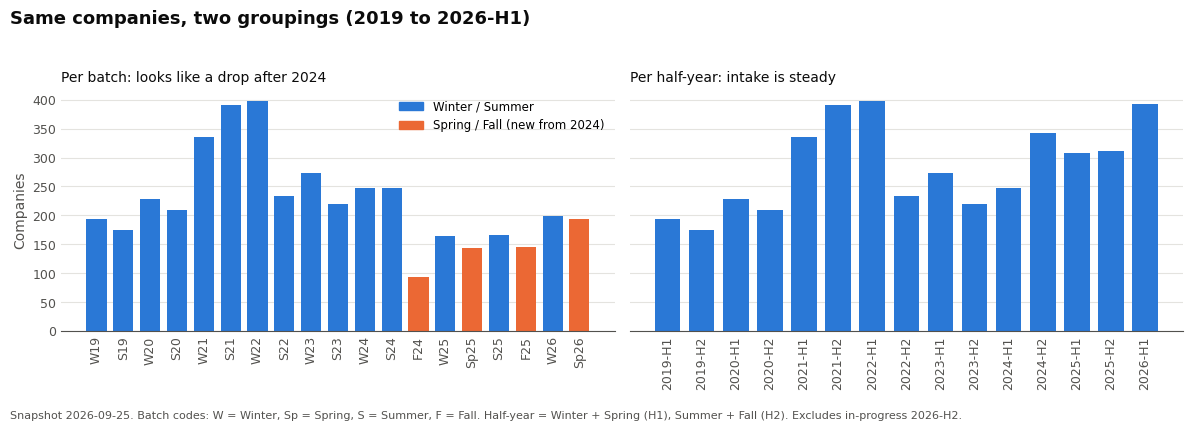

In [23]:
# C5 · Why consolidate: per-batch counts show a false decline (Finding 4)
SEASON_ORDER = {"Winter": 1, "Spring": 2, "Summer": 3, "Fall": 4}
def batch_key(label):
    season, year = label.split()
    return (int(year), SEASON_ORDER[season])

recent = df[df["period"].between("2019-H1", "2026-H1")]
per_batch = recent["batch"].value_counts()
per_batch = per_batch.reindex(sorted(per_batch.index, key=batch_key))
per_period = recent["period"].value_counts().sort_index()

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)
new_season = [b.split()[0] in ("Spring", "Fall") for b in per_batch.index]
a1.bar(range(len(per_batch)), per_batch.values, width=0.75,
       color=[PALETTE[1] if n else BLUE for n in new_season])
a1.set_xticks(range(len(per_batch)), [{"Winter": "W", "Spring": "Sp", "Summer": "S", "Fall": "F"}[b.split()[0]] + b[-2:]
                                      for b in per_batch.index], rotation=90)
a1.set_title("Per batch: looks like a drop after 2024", loc="left", fontsize=10, color=INK)
from matplotlib.patches import Patch
a1.legend(handles=[Patch(color=BLUE, label="Winter / Summer"),
                   Patch(color=PALETTE[1], label="Spring / Fall (new from 2024)")],
          frameon=False, fontsize=8.5, loc="upper right")
a2.bar(range(len(per_period)), per_period.values, width=0.75, color=BLUE)
a2.set_xticks(range(len(per_period)), list(per_period.index), rotation=90)
a2.set_title("Per half-year: intake is steady", loc="left", fontsize=10, color=INK)
for a in (a1, a2):
    style(a)
a1.set_ylabel("Companies", color=MUTED)
titled(fig, "Same companies, two groupings (2019 to 2026-H1)",
       f"Snapshot {snapshot}. Batch codes: W = Winter, Sp = Spring, S = Summer, F = Fall. "
       "Half-year = Winter + Spring (H1), Summer + Fall (H2). Excludes in-progress 2026-H2.")
plt.show()

### Finding 4: Batch structure and half-year periods

**Four seasons since 2024–25.** Batch labels include Winter, Spring, Summer,
and Fall. Fall appears from 2024 and Spring from 2025, when YC moved from two
to four batches a year. Per-batch counts after this change are not comparable
with earlier batches: the same intake is split across twice as many batches,
which would show a false decline.

**Consolidation to half-year periods.** Batches are mapped to periods
(Winter + Spring → H1, Summer + Fall → H2), so each period covers about six
months of YC intake regardless of cadence. After consolidation, post-2024
periods (248–392 companies) sit in the same range as 2021–2023 (220–398).
*Season timing to be confirmed against YC's announcement of the four-batch
schedule.*

**Tie-out.** 2026-H1 = 392 = Winter 2026 (199) + Spring 2026 (193).
2025-H1 = 308 = Winter 2025 (165) + Spring 2025 (143).

**Series overview.** Continuous from 2005-H2 with no gaps. Intake grows from
single digits (2005–2009) to a peak in 2021–2022-H1 (335–398), drops in
2022-H2 (233), then recovers to 300–400 per half-year from 2024-H2.

**Excluded from trend analysis:**

| Period / batch | Companies | Reason |
|---|---|---|
| 2026-H2 | 321 | Includes Fall 2026 (91), a batch still in progress and only partly listed |
| 2027-H1 (Winter 2027) | 1 | Future-dated; YC's own page shows the same batch (spot check) |
| 2027-H2 (Summer 2027) | 1 | Future-dated; YC's own page shows the same batch (spot check) |
| Unspecified | 1 | Cannot be placed in time |

**Why the in-progress batch is incomplete.** Fall 2026 was in progress on
the snapshot date (2026-09-25). YC adds companies to its directory gradually,
sometimes weeks or months after a batch starts, so the listed count grows while
the batch runs: 23 Fall 2026 companies were listed on 2026-08-27
([Frontrun](https://www.frontrun.vc/blog/yc-f26-companies-full-list/)) versus
91 in this snapshot. Comparing it with a finished batch (e.g. Fall 2025, 146
companies) would show a false decline, even season-to-season. Fall 2026
companies remain in company-level views, labelled "batch in progress."
*To verify with own data: re-download in 2–3 weeks and compare the Fall 2026
count.*

**Rule for future re-runs:** exclude the latest period if its most recent
batch is still in progress, and exclude any future-dated batch. The rule is
based on batch status, not on whether the count looks low (2026-H2 looks
normal at 321 but is incomplete).

**Implications for the founder use case:**
- "Recent" should mean the latest complete periods, e.g. the last two
  complete half-years compared with the two before them.
- Periods before about 2011 have fewer than 50 companies in total, so
  subindustry shares will be noisy there; the dashboard may need to start
  around 2012 or show counts alongside shares.
- Small subindustries may need yearly rather than half-year periods to show
  a readable trend (open question for YC-12).

### Companies by industry over time

Complete half-year periods only (see Finding 4). The first chart shows the
number of companies; the second shows each industry's share of its
half-year, so growth in YC overall doesn't hide shifts between industries.

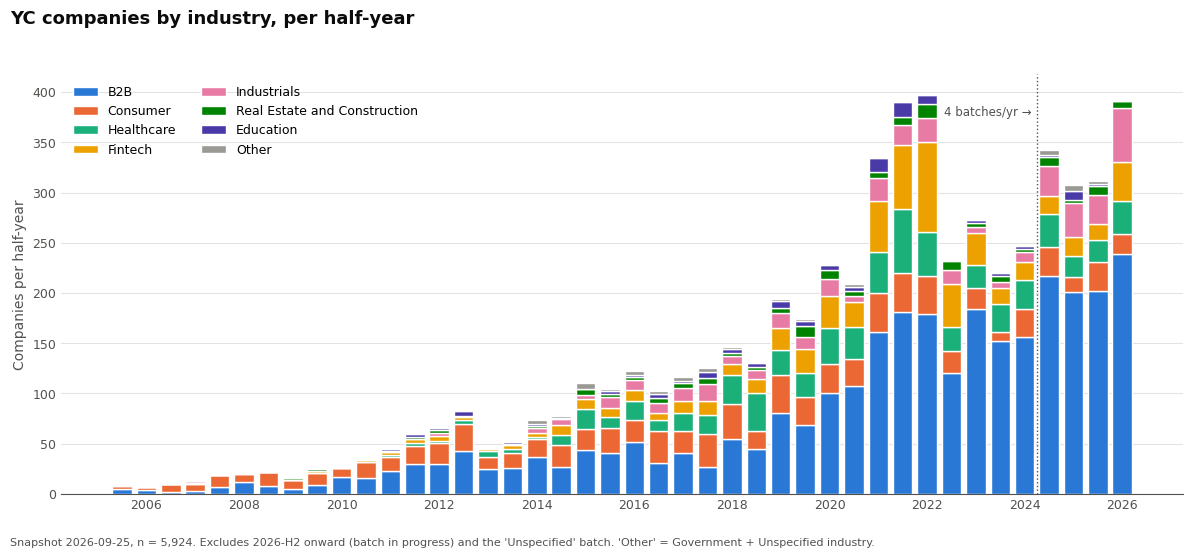

In [24]:
# C6a · Companies by industry, per half-year (counts)
trend = df[df["period"].notna() & (df["period"] < cutoff)].copy()
ORDER = ["B2B", "Consumer", "Healthcare", "Fintech", "Industrials",
         "Real Estate and Construction", "Education", "Other"]      # 8 colours max
trend["industry_group"] = trend["industry"].where(trend["industry"].isin(ORDER[:-1]), "Other")
counts = (trend.pivot_table(index="period", columns="industry_group",
                            values="id", aggfunc="count", fill_value=0)
               .reindex(columns=ORDER, fill_value=0))
shares = counts.div(counts.sum(axis=1), axis=0)
periods = list(counts.index)
xs = range(len(periods))
ticks = [i for i, p in enumerate(periods) if p.endswith("H1") and int(p[:4]) % 2 == 0]

fig, ax = plt.subplots(figsize=(12, 5.5))
bottom = pd.Series(0, index=counts.index)
for ind_name, col in zip(ORDER, PALETTE):
    ax.bar(xs, counts[ind_name], bottom=bottom, color=col, width=0.8,
           edgecolor="white", linewidth=1, label=ind_name)
    bottom += counts[ind_name]
style(ax)
ax.set_xticks(ticks, [periods[i][:4] for i in ticks])
ax.set_ylabel("Companies per half-year", color=MUTED)
cad = periods.index("2024-H2")
ax.axvline(cad - 0.5, color=MUTED, linestyle=":", linewidth=1)
ax.text(cad - 0.7, bottom.max() * 0.97, "4 batches/yr →", ha="right", va="top", fontsize=8.5, color=MUTED)
ax.legend(loc="upper left", frameon=False, fontsize=9, ncol=2)
titled(fig, "YC companies by industry, per half-year",
       f"Snapshot {snapshot}, n = {len(trend):,}. Excludes {cutoff} onward (batch in progress) and the "
       "'Unspecified' batch. 'Other' = Government + Unspecified industry.")
plt.show()

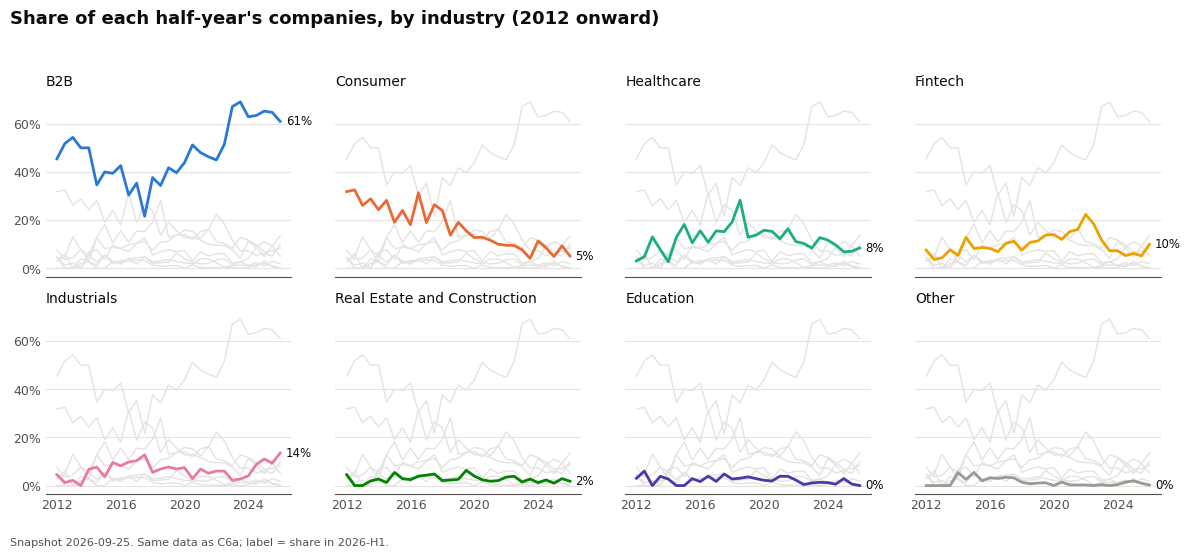

In [25]:
# C6b · Share of each industry, per half-year (small multiples, from 2012)
START = "2012-H1"                       # earlier periods have < 70 companies: shares too noisy
sh = shares[shares.index >= START]
px = range(len(sh))
fig, axes = plt.subplots(2, 4, figsize=(12, 5.5), sharex=True, sharey=True)
for ax, ind_name, col in zip(axes.flat, ORDER, PALETTE):
    for other in ORDER:                                  # faint context lines
        if other != ind_name:
            ax.plot(px, sh[other], color=GRID, linewidth=1)
    ax.plot(px, sh[ind_name], color=col, linewidth=2)
    style(ax)
    ax.set_title(ind_name, loc="left", fontsize=10, color=INK)
    last = sh[ind_name].iloc[-1]
    ax.annotate(f"{last:.0%}", (len(sh) - 1, last), xytext=(4, 0),
                textcoords="offset points", fontsize=8.5, color=INK, va="center")
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
    t = [i for i, p in enumerate(sh.index) if p.endswith("H1") and int(p[:4]) % 4 == 0]
    ax.set_xticks(t, [sh.index[i][:4] for i in t])
titled(fig, f"Share of each half-year's companies, by industry ({START[:4]} onward)",
       f"Snapshot {snapshot}. Same data as C6a; label = share in {sh.index[-1]}.")
plt.show()

## 6. Spot-check sample (20 companies)

Picks a reproducible stratified sample: old vs recent batches, active vs not.
Open each `url` **by hand**, compare name / batch / status / industry, and fill in `docs/spot_check.csv`.

In [26]:

def batch_year(b):
    try:
        return int(str(b).split()[-1])
    except (ValueError, IndexError):
        return None

s = df.assign(year=df["batch"].map(batch_year),
              is_active=df["status"].eq("Active"))
s["era"] = pd.cut(s["year"], bins=[0, 2014, 2020, 9999], labels=["early", "middle", "recent"])

# Shuffle once (fixed seed = reproducible), then take up to 4 per era × active group
sample = (s.dropna(subset=["era"])
           .sample(frac=1, random_state=7)
           .groupby(["era", "is_active"], observed=True)
           .head(4))
sample = sample.head(20)[["id", "name", "batch", "status", "industry", "url"]]

sample_path = ROOT / "docs" / "spot_check.csv"
out = sample.assign(name_ok="", batch_ok="", status_ok="", industry_ok="", notes="")
if not sample_path.exists():                     # never overwrite your manual results
    out.to_csv(sample_path, index=False)
    print("Wrote", sample_path)
else:
    print(sample_path, "already exists; not overwritten")
sample

c:\Users\dqthi\PlayGroundCoding\ycPortfolioAnalysis\yc-portfolio-analytics\docs\spot_check.csv already exists; not overwritten


,id,name,batch,status,industry,url
2117,13168,Infield,Winter 2020,Active,B2B,https://www.ycombinator.com/companies/infield
4360,29253,Andon Labs,Winter 2024,Active,B2B,https://www.ycombinator.com/companies/andon-labs
5603,31092,Axis,Winter 2026,Active,Fintech,https://www.ycombinator.com/companies/axis-2
2409,22079,Formal,Summer 2020,Active,B2B,https://www.ycombinator.com/companies/formal
3770,27109,HOMLI,Summer 2022,Active,Real Estate and Construction,https://www.ycombinator.com/companies/homli
5528,30964,Sava,Fall 2025,Active,Fintech,https://www.ycombinator.com/companies/savahq
798,842,Raven Tech,Winter 2015,Acquired,B2B,https://www.ycombinator.com/companies/raven-tech
966,1026,Open Motors,Winter 2016,Inactive,Industrials,https://www.ycombinator.com/companies/open-motors
4062,28119,Fabius,Winter 2023,Inactive,B2B,https://www.ycombinator.com/companies/fabius
640,665,Craft Coffee,Summer 2014,Acquired,Consumer,https://www.ycombinator.com/companies/craft-co...


The two future-dated companies (Winter 2027, Summer 2027) were added to
`docs/spot_check.csv` separately and checked by hand; the cell below lists them.

In [27]:
df[df["batch"].isin(["Winter 2027", "Summer 2027"])][["name", "batch", "status", "url"]]

,name,batch,status,url
6004,Rote,Winter 2027,Active,https://www.ycombinator.com/companies/rote
6231,Memorable,Summer 2027,Active,https://www.ycombinator.com/companies/memorable


## 7. Verdict: **Go, with caveats**

**Q1 (founder: is my solution space getting crowded in recent YC batches?)**
can be answered with the yc-oss feed, used under the rules below.

**Why go**
- The mirror is faithful: 22 of 22 spot-checked companies matched YC's own
  directory on name, batch, status and industry.
- Identity is clean (no missing or duplicate IDs), and the key fields are
  nearly complete: `one_liner` 2.6% missing, `industry` and `batch` 0%.
- `subindustry` provides a usable application level (e.g. `B2B -> Legal`).

**Caveats (these become design rules)**
1. **Define a space by subindustry + keyword in `one_liner`**, not by tags.
   Tags are unreliable for recent companies (about 74% of 2026-H1 untagged)
   and mix application and technology labels.
2. **Show trends by half-year period, complete periods only.** Exclude the
   in-progress Fall 2026 batch (2026-H2 onward), future-dated batches, and
   "Unspecified." Per-batch counts would show a false decline after 2024.
3. **"Crowded" means crowded within YC's public directory**, not the whole
   market: launched companies only, labels as of the snapshot date, and no
   funding or performance data.

**Minor limitations:** 18.7% of companies have no child subindustry (about
30% from 2024 onward); `stage` has only two values; the source is an
unofficial mirror whose relationship to YC's terms is unclear.

**Q2 (founder backgrounds):** not answerable from this feed. Pending YC-9
(permission request to YC) and YC-10 (30-founder manual spike).

**Next:** caveats feed YC-12 (brief: out of scope, success criteria) and
`docs/source_register.md`; Sprint 1 starts with the half-year period field
and the subindustry + keyword space definition.
